In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [ ]:
dados = pd.read_excel('dados_admissao.xlsx')

In [ ]:
# Remover colunas que não serão utilizadas
dados.drop(columns=['Serial No.'], inplace=True)

In [ ]:
# Variáveis métricas

print(dados[['GRE', 'TOEFL', 'SOP', 'LOR', 'CGPA', 'Score']].describe())

In [ ]:
# Variáveis categóricas

print(dados['UniversityRating'].value_counts())
print(dados['Research'].value_counts())

In [ ]:
# Transformando variáveis explicativas categóricas em dummies

dados = pd.get_dummies(dados,
                       columns=['UniversityRating'],
                       drop_first=False,
                       dtype='int')

In [ ]:
# Separando as variáveis Y e X

X = dados.drop(columns=['Score'])
y = dados['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=100)

In [ ]:
# Gerando a árvore de decisão

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=100)
tree_reg.fit(X_train, y_train)

# Plotando a árvore

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_reg,
          feature_names=X.columns.tolist(),
          filled=True,
          node_ids=True,
          precision=2)
plt.show()

In [ ]:
# Analisando os resultados dos splits

tree_split = pd.DataFrame(tree_reg.cost_complexity_pruning_path(X_train, y_train))
tree_split.sort_index(ascending=False, inplace=True)

print(tree_split)

In [ ]:
# Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_reg.feature_importances_})

print(tree_features)

In [ ]:
# Obtendo os valores preditos pelo modelo

# Base de treinamento
tree_pred_train = tree_reg.predict(X_train)

# Base de teste
tree_pred_test = tree_reg.predict(X_test)

In [ ]:
# Avaliando o modelo (base de treino)

mse_train_tree = mean_squared_error(y_train, tree_pred_train)
mae_train_tree = mean_absolute_error(y_train, tree_pred_train)
r2_train_tree = r2_score(y_train, tree_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_tree:.1f}")
print(f"RMSE: {np.sqrt(mse_train_tree):.1f}")
print(f"MAE: {mae_train_tree:.1f}")
print(f"R²: {r2_train_tree:.1%}")

In [ ]:
# Avaliando o modelo (base de testes)

mse_test_tree = mean_squared_error(y_test, tree_pred_test)
mae_test_tree = mean_absolute_error(y_test, tree_pred_test)
r2_test_tree = r2_score(y_test, tree_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_tree:.1f}")
print(f"RMSE: {np.sqrt(mse_test_tree):.1f}")
print(f"MAE: {mae_test_tree:.1f}")
print(f"R²: {r2_test_tree:.1%}")

In [ ]:
# Vamos aplicar um Grid Search
param_grid_tree = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [5, 10]
}

# Identificar o algoritmo em uso
tree_grid = DecisionTreeRegressor(random_state=100)

# Treinar os modelos para o grid search
tree_grid_model = GridSearchCV(estimator = tree_grid,
                               param_grid = param_grid_tree,
                               scoring='neg_mean_squared_error', # Atenção à metrica de avaliação!
                               cv=5, verbose=2)

tree_grid_model.fit(X_train, y_train)

# Verificando os melhores parâmetros obtidos
tree_grid_model.best_params_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=15; total time=   0.0s
[CV] END max_depth=3, min_sampl

{'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 5}

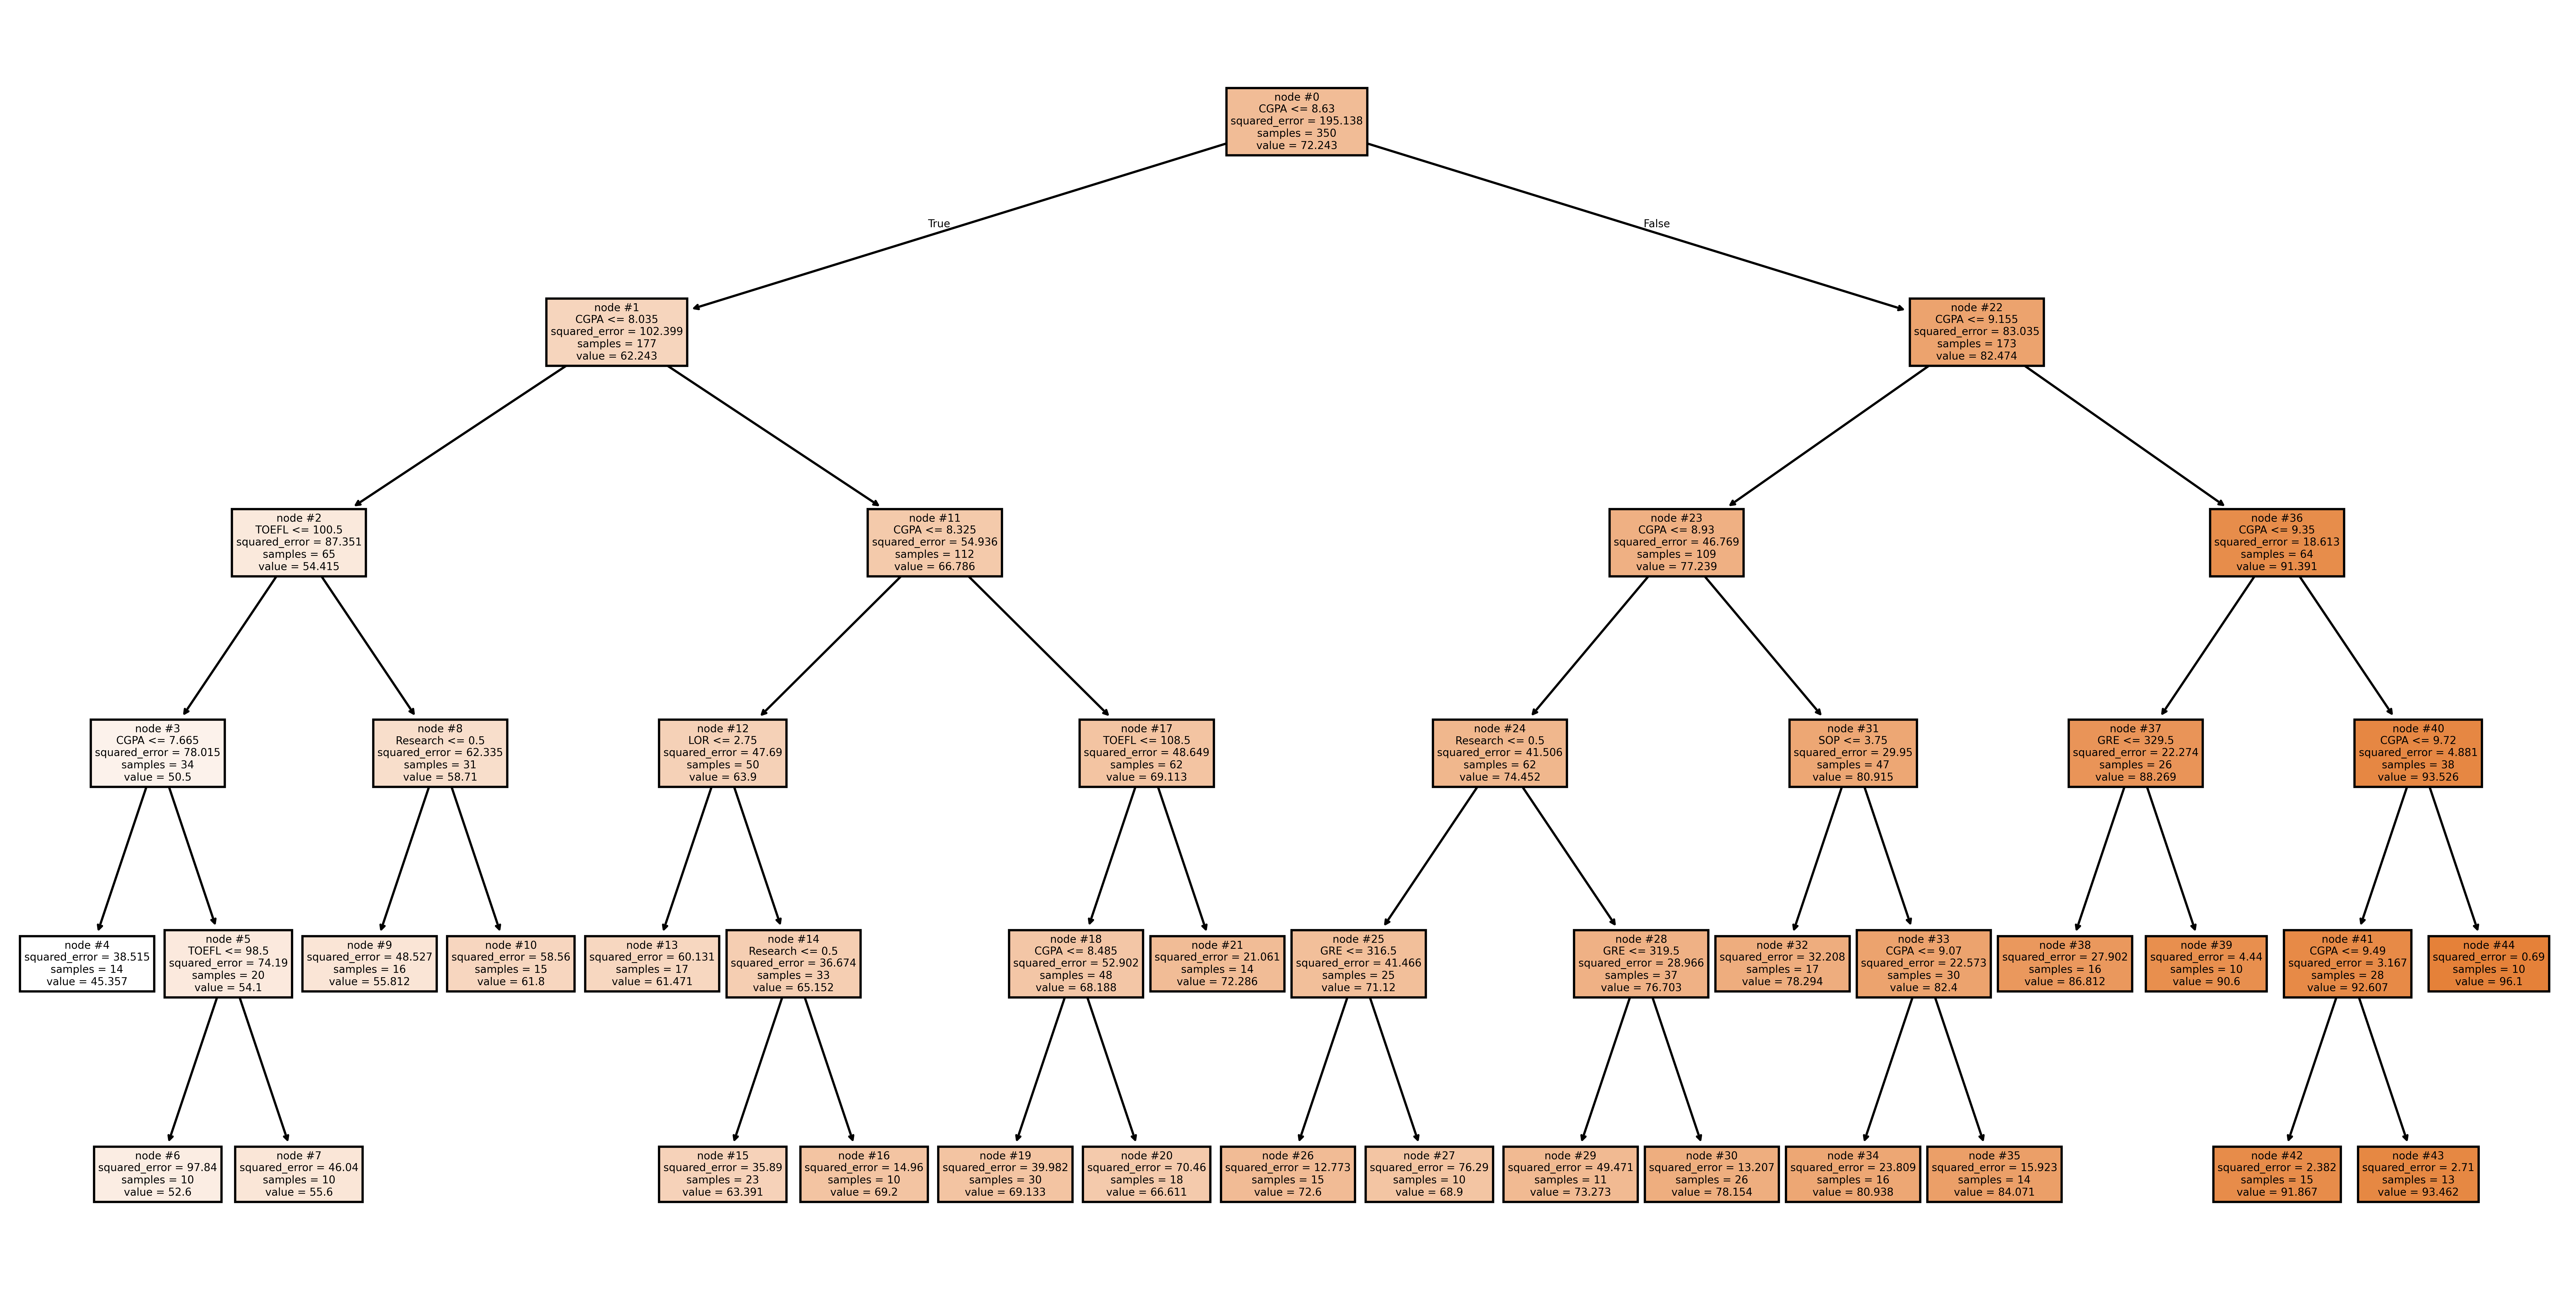

In [ ]:
# Gerando o modelo com os melhores hiperparâmetros
tree_best = tree_grid_model.best_estimator_

# Predict do modelo
tree_grid_pred_train = tree_best.predict(X_train)
tree_grid_pred_test = tree_best.predict(X_test)

# Plotando a árvore após o grid search

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_best,
          feature_names=X.columns.tolist(),
          filled=True,
          node_ids=True)
plt.show()

In [ ]:
#%% Avaliando o novo modelo (base de treino)

mse_train_tree_grid = mean_squared_error(y_train, tree_grid_pred_train)
mae_train_tree_grid = mean_absolute_error(y_train, tree_grid_pred_train)
r2_train_tree_grid = r2_score(y_train, tree_grid_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_tree_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_train_tree_grid):.1f}")
print(f"MAE: {mae_train_tree_grid:.1f}")
print(f"R²: {r2_train_tree_grid:.1%}")


In [ ]:
#%% Avaliando o novo modelo (base de teste)

mse_test_tree_grid = mean_squared_error(y_test, tree_grid_pred_test)
mae_test_tree_grid = mean_absolute_error(y_test, tree_grid_pred_test)
r2_test_tree_grid = r2_score(y_test, tree_grid_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_tree_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_test_tree_grid):.1f}")
print(f"MAE: {mae_test_tree_grid:.1f}")
print(f"R²: {r2_test_tree_grid:.1%}")

In [ ]:
# Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_best.feature_importances_}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(tree_features)

In [ ]:
# Gráfico fitted values

# Valores preditos pelo modelo para as observações da amostra de teste
graph = pd.DataFrame({'Score': y_test,
                      'pred_tree': tree_grid_pred_test})

plt.figure(dpi=600)
sns.scatterplot(graph, x='Score', y='pred_tree', color='purple')
plt.title('Analisando as Previsões', fontsize=10)
plt.xlabel('Score Observado', fontsize=10)
plt.ylabel('Score Previsto pelo Modelo', fontsize=10)
plt.axline((25, 25), (max(dados['Score']), max(dados['Score'])), linewidth=1, color='grey')
plt.show()

In [ ]:
# É possível avaliar outros modelos:
    # Random Forest: RandomForestRegressor()
    # XGBoost: XGBRegressor()

In [ ]:
# Vamos aplicar um Grid Search
param_grid_rf = {
    'n_estimators': [100, 500],
    'max_depth': [5, 10],
    'max_features': [3, 5, 7],
    'min_samples_leaf': [30, 50]
}

# Identificar o algoritmo em uso
rf_grid = RandomForestRegressor(random_state=100)

# Treinar os modelos para o grid search
rf_grid_model = GridSearchCV(estimator = rf_grid,
                             param_grid = param_grid_rf,
                             scoring='neg_mean_squared_error', # Atenção à metrica de avaliação!
                             cv=5, verbose=2)

rf_grid_model.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=500; total time=   1.0s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=500; total time=   0.7s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=500; total time=   0.7s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=500; total time=   0.7s
[CV] END max_depth=5, max_features=3, min_samples_leaf=30, n_estimators=50

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=100),
             param_grid={'max_depth': [5, 10], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [30, 50],
                         'n_estimators': [100, 500]},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
# Verificando os melhores parâmetros obtidos
rf_grid_model.best_params_

# Gerando o modelo com os melhores hiperparâmetros
rf_best = rf_grid_model.best_estimator_

# Predict do modelo
rf_grid_pred_train = rf_best.predict(X_train)
rf_grid_pred_test = rf_best.predict(X_test)

# Importância das variáveis preditoras

rf_features = pd.DataFrame({'features':X.columns.tolist(),
                            'importance':np.round(rf_best.feature_importances_, 4)}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(rf_features)

              features  importance
0                 CGPA      0.6632
1                  GRE      0.2061
2                TOEFL      0.1040
3                  SOP      0.0126
4                  LOR      0.0085
5             Research      0.0034
6   UniversityRating_2      0.0018
7   UniversityRating_3      0.0005
8   UniversityRating_1      0.0000
9   UniversityRating_4      0.0000
10  UniversityRating_5      0.0000


In [ ]:
# Avaliando a RF (base de treino)

mse_train_rf_grid = mean_squared_error(y_train, rf_grid_pred_train)
mae_train_rf_grid = mean_absolute_error(y_train, rf_grid_pred_train)
r2_train_rf_grid = r2_score(y_train, rf_grid_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_rf_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_train_rf_grid):.1f}")
print(f"MAE: {mae_train_rf_grid:.1f}")
print(f"R²: {r2_train_rf_grid:.1%}")

Avaliação do Modelo (Base de Treino)
MSE: 39.7
RMSE: 6.3
MAE: 4.5
R²: 79.7%


In [ ]:
# Avaliando a RF (base de teste)

mse_test_rf_grid = mean_squared_error(y_test, rf_grid_pred_test)
mae_test_rf_grid = mean_absolute_error(y_test, rf_grid_pred_test)
r2_test_rf_grid = r2_score(y_test, rf_grid_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_rf_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_test_rf_grid):.1f}")
print(f"MAE: {mae_test_rf_grid:.1f}")
print(f"R²: {r2_test_rf_grid:.1%}")

Avaliação do Modelo (Base de Teste)
MSE: 40.9
RMSE: 6.4
MAE: 4.8
R²: 80.3%


In [ ]:
# Vamos aplicar um Grid Search
param_grid_xgb = {
    'n_estimators': [100, 500, 700],
    'max_depth': [3, 5],
    'learning_rate': [0.001, 0.01, 0.1],
    'colsample_bytree': [0.5, 0.8],
}

# Identificar o algoritmo em uso
xgb_grid = XGBRegressor(random_state=100)

# Treinar os modelos para o grid search
xgb_grid_model = GridSearchCV(estimator = xgb_grid,
                             param_grid = param_grid_xgb,
                             scoring='neg_mean_squared_error', # Atenção à metrica de avaliação!
                             cv=5, verbose=2)

xgb_grid_model.fit(X_train, y_train)

In [ ]:
# Verificando os melhores parâmetros obtidos
xgb_grid_model.best_params_

# Gerando o modelo com os melhores hiperparâmetros
xgb_best = xgb_grid_model.best_estimator_

# Predict do modelo
xgb_grid_pred_train = xgb_best.predict(X_train)
xgb_grid_pred_test = xgb_best.predict(X_test)

#%% Importância das variáveis preditoras

xgb_features = pd.DataFrame({'features':X.columns.tolist(),
                             'importance':np.round(xgb_best.feature_importances_, 4)}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(xgb_features)

              features  importance
0                 CGPA      0.4060
1                  GRE      0.2007
2                TOEFL      0.1194
3                  SOP      0.0796
4                  LOR      0.0515
5             Research      0.0449
6   UniversityRating_5      0.0241
7   UniversityRating_3      0.0232
8   UniversityRating_2      0.0224
9   UniversityRating_4      0.0143
10  UniversityRating_1      0.0137


In [ ]:
# Avaliando o XGB (base de treino)

mse_train_xgb_grid = mean_squared_error(y_train, xgb_grid_pred_train)
mae_train_xgb_grid = mean_absolute_error(y_train, xgb_grid_pred_train)
r2_train_xgb_grid = r2_score(y_train, xgb_grid_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_xgb_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_train_xgb_grid):.1f}")
print(f"MAE: {mae_train_xgb_grid:.1f}")
print(f"R²: {r2_train_xgb_grid:.1%}")

In [ ]:
# Avaliando o XGB (base de teste)

mse_test_xgb_grid = mean_squared_error(y_test, xgb_grid_pred_test)
mae_test_xgb_grid = mean_absolute_error(y_test, xgb_grid_pred_test)
r2_test_xgb_grid = r2_score(y_test, xgb_grid_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_xgb_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_test_xgb_grid):.1f}")
print(f"MAE: {mae_test_xgb_grid:.1f}")
print(f"R²: {r2_test_xgb_grid:.1%}")